# Laboratorio 4 — Parte 2
## Modelos de Machine Learning para detectar zonas con alta presencia de cianobacteria

**CC3084 – Data Science | Semestre II 2026**

Integrantes:
- Daniel Oswaldo Juárez Herrera
- Humberto Alexander de la Cruz
- Nicolle Alexandra Gordillo

---

### Punto de partida

Este notebook parte de los rásteres generados en la **Parte I**, que ya están en disco:

| Archivo | Contenido |
|---|---|
| `datos/raw/<lago>/<lago>_<fecha>.tif` | 10 bandas Sentinel-2 L2A (B02, B03, B04, B05, B07, B08, B8A, B11, B12, SCL) |
| `datos/indices/<lago>/<lago>_<fecha>_indices.tif` | 8 capas: ndci, chla, fai, ndvi, ndwi, agua, valido, nata |
| `datos/indices/mascara_<lago>.tif` | Espejo de agua del lago (límite oficial de OpenStreetMap) |


## Configuración

In [41]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as warp_transform
from scipy import ndimage
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

RAIZ        = Path.cwd()
DIR_RAW     = RAIZ / "datos" / "raw"
DIR_INDICES = RAIZ / "datos" / "indices"
DIR_RES     = RAIZ / "resultados"
DIR_FIG     = DIR_RES / "figuras_ml"
DIR_ML      = RAIZ / "datos" / "ml"
for d in (DIR_RES, DIR_FIG, DIR_ML): d.mkdir(parents=True, exist_ok=True)

NOMBRE = {"atitlan": "Lago de Atitlán", "amatitlan": "Lago de Amatitlán"}
COLOR  = {"atitlan": "#1b6ca8", "amatitlan": "#c0392b"}

# Mismas fechas de la Parte I
FECHAS = {
    "atitlan": ["2025-01-18","2025-04-13","2025-05-13","2025-07-17","2025-11-21",
                "2025-12-29","2026-02-12","2026-03-24","2026-04-13","2026-04-28","2026-07-22"],
    "amatitlan": ["2025-01-28","2025-04-15","2025-04-28","2025-11-24","2026-01-08","2026-02-02",
                  "2026-02-07","2026-03-29","2026-04-13","2026-04-28","2026-06-19"],
}
LAGOS = list(FECHAS)

# Fechas excluidas en la Parte I por problemas de calidad de datos
FECHAS_DESCARTADAS = {("atitlan", "2025-01-18")}

BANDAS_RAW = ["B02","B03","B04","B05","B07","B08","B8A","B11","B12","SCL"]
CAPAS_IDX  = ["ndci","chla","fai","ndvi","ndwi","agua","valido","nata"]
SCL_INVALIDAS = {0, 1, 3, 8, 9, 10}

# --- Variable respuesta (ver ejercicio 2) ---
UMBRAL_CHLA = 10.0        # µg/L, Nivel de Alerta 1 de la OMS
UMBRAL_NDCI = 0.2413      # NDCI equivalente al corte anterior

# --- Muestreo (ver ejercicio 1.3) ---
MAX_POR_FECHA = 15000     # observaciones por lago y fecha
SEMILLA = 42

CRS_METRICO = "EPSG:32615"   # WGS84 / UTM 15N, requerido para el ejercicio 6
PARQUET = DIR_ML / "dataset_ml.parquet"

ruta_raw = lambda l, f: DIR_RAW / l / f"{l}_{f}.tif"
ruta_idx = lambda l, f: DIR_INDICES / l / f"{l}_{f}_indices.tif"
estacion = lambda f: "Lluviosa" if int(f[5:7]) in {5,6,7,8,9,10} else "Seca"

---
# Ejercicio 1 — Preparación del conjunto de datos

## 1.1 – 1.3 Construcción del conjunto de datos

Cada fila del conjunto será un píxel de agua en una fecha concreta: la unidad de observación natural del problema, porque es el nivel al que el satélite mide y al que después habrá que predecir.

Se descartan, en este orden:

1. Píxeles fuera del espejo de agua, usando la máscara del lago de la Parte I.
2. Píxeles con nube, sombra de nube, cirros, saturación o sin dato, según la clasificación de escena (SCL) que acompaña a cada imagen.
3. Píxeles con reflectancia negativa o nula en las bandas del índice, donde el NDCI se sale de su rango físico. Es el mismo control que en la Parte I dejó fuera la imagen de Atitlán del 18/01/2025, que se excluye completa.
4. Píxeles con algún valor faltante en las variables que se usarán.

El conjunto completo tendría del orden de 2.8 millones de filas, con Atitlán aportando ocho veces más píxeles que Amatitlán solo por ser más grande. Eso trae dos problemas: el costo computacional de SHAP y del ajuste de hiperparámetros más adelante, y que el lago grande dominaría el entrenamiento por razones geométricas y no ecológicas. Se toma entonces una muestra aleatoria de hasta 15,000 píxeles por lago y fecha, lo que equilibra ambos lagos y mantiene un tamaño manejable. Los píxeles vecinos son fuertemente redundantes entre sí (autocorrelación espacial), así que el muestreo no sacrifica información real. La máscara completa se conserva en disco para reconstruir los mapas predictivos del ejercicio 9.

In [42]:
def leer_fecha(lago, fecha):
    "Devuelve un DataFrame con un renglón por píxel válido de esa fecha."
    if (lago, fecha) in FECHAS_DESCARTADAS or not ruta_idx(lago, fecha).exists():
        return None

    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as s:
        lago_m = s.read(1).astype(bool)
    with rasterio.open(ruta_idx(lago, fecha)) as s:
        idx = {n: s.read(i+1) for i, n in enumerate(CAPAS_IDX)}
        transformacion = s.transform
    with rasterio.open(ruta_raw(lago, fecha)) as s:
        crudo = s.read().astype(np.float32)

    bandas = {n: crudo[i] for i, n in enumerate(BANDAS_RAW)}
    scl = bandas.pop("SCL")

    # Escalado automático de reflectancia (openEO entrega enteros 0-10000)
    m = bandas["B04"][np.isfinite(bandas["B04"])]
    if m.size and np.nanpercentile(m, 99) > 1.5:
        bandas = {k: v/10000.0 for k, v in bandas.items()}

    # --- filtros ---
    valido = ~np.isin(np.rint(scl).astype(np.int16), list(SCL_INVALIDAS))
    valido &= idx["valido"].astype(bool)
    valido &= (bandas["B04"] > 0) & (bandas["B05"] > 0)      # rango físico del índice
    valido &= np.isfinite(idx["ndci"]) & np.isfinite(idx["chla"])
    sel = lago_m & valido
    if sel.sum() == 0:
        return None

    filas, cols = np.where(sel)

    # Coordenadas geográficas del centro de cada píxel
    xs, ys = rasterio.transform.xy(transformacion, filas, cols)

    # Distancia al borde del lago, en metros (característica espacial, ver 3.3)
    tamano_px = abs(transformacion.a) * 111320 * np.cos(np.radians(np.mean(ys)))
    dist_orilla = ndimage.distance_transform_edt(lago_m) * tamano_px

    d = {"lago": lago, "fecha": fecha, "fila": filas, "col": cols,
         "lon": np.asarray(xs, np.float32), "lat": np.asarray(ys, np.float32),
         "dist_orilla_m": dist_orilla[filas, cols].astype(np.float32)}
    for n, a in bandas.items():
        d[n] = a[filas, cols].astype(np.float32)
    for n in ("ndci", "chla", "fai", "ndvi", "ndwi", "nata"):
        d[n] = idx[n][filas, cols].astype(np.float32)
    return pd.DataFrame(d)


def construir_dataset(max_por_fecha=MAX_POR_FECHA, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    partes, inventario = [], []
    for lago in LAGOS:
        for fecha in FECHAS[lago]:
            df_f = leer_fecha(lago, fecha)
            if df_f is None:
                inventario.append((lago, fecha, 0, 0, "descartada"))
                continue
            n_total = len(df_f)
            if max_por_fecha and n_total > max_por_fecha:
                df_f = df_f.iloc[rng.choice(n_total, max_por_fecha, replace=False)]
            partes.append(df_f)
            inventario.append((lago, fecha, n_total, len(df_f), "ok"))
            print(f"  {lago:10s} {fecha}: {n_total:>8,} píxeles válidos -> "
                  f"{len(df_f):>7,} en la muestra")
    df = pd.concat(partes, ignore_index=True)
    inv = pd.DataFrame(inventario, columns=["lago","fecha","pixeles_validos",
                                            "en_muestra","estado"])
    return df, inv

print("Construyendo el conjunto de datos...\n")
df, inventario = construir_dataset()
df["fecha"] = pd.to_datetime(df["fecha"])
df["estacion"] = df["fecha"].dt.month.map(lambda m: "Lluviosa" if m in {5,6,7,8,9,10} else "Seca")
print(f"\nTotal de observaciones: {len(df):,}")
df.head()

Construyendo el conjunto de datos...

  atitlan    2025-04-13:  261,548 píxeles válidos ->  15,000 en la muestra
  atitlan    2025-05-13:  261,523 píxeles válidos ->  15,000 en la muestra
  atitlan    2025-07-17:  261,116 píxeles válidos ->  15,000 en la muestra
  atitlan    2025-11-21:  248,633 píxeles válidos ->  15,000 en la muestra
  atitlan    2025-12-29:  246,382 píxeles válidos ->  15,000 en la muestra
  atitlan    2026-02-12:  222,288 píxeles válidos ->  15,000 en la muestra
  atitlan    2026-03-24:  261,543 píxeles válidos ->  15,000 en la muestra
  atitlan    2026-04-13:  261,395 píxeles válidos ->  15,000 en la muestra
  atitlan    2026-04-28:  261,554 píxeles válidos ->  15,000 en la muestra
  atitlan    2026-07-22:  261,498 píxeles válidos ->  15,000 en la muestra
  amatitlan  2025-01-28:   31,447 píxeles válidos ->  15,000 en la muestra
  amatitlan  2025-04-15:   31,453 píxeles válidos ->  15,000 en la muestra
  amatitlan  2025-04-28:   31,452 píxeles válidos ->  15,000 e

,lago,fecha,fila,col,lon,lat,dist_orilla_m,B02,B03,B04,...,B8A,B11,B12,ndci,chla,fai,ndvi,ndwi,nata,estacion
0,atitlan,2025-04-13,68,752,-91.175758,14.737279,385.242157,0.0393,0.0330,0.0199,...,0.0190,0.0158,0.0144,-0.017903,3.669557,0.000031,-0.023136,0.269231,0.0,Seca
1,atitlan,2025-04-13,249,539,-91.218353,14.701079,3274.912354,0.0323,0.0244,0.0105,...,0.0110,0.0059,0.0047,0.014085,4.305916,-0.000595,-0.009615,0.406340,0.0,Seca
2,atitlan,2025-04-13,310,703,-91.185555,14.688879,1595.967651,0.0317,0.0237,0.0133,...,0.0123,0.0090,0.0071,-0.031008,3.287576,0.000790,-0.019157,0.298630,0.0,Seca
3,atitlan,2025-04-13,271,788,-91.168556,14.696679,2221.936523,0.0383,0.0319,0.0186,...,0.0158,0.0113,0.0094,-0.044944,2.785650,-0.001248,-0.044944,0.304703,0.0,Seca
4,atitlan,2025-04-13,259,573,-91.211555,14.699079,3284.245850,0.0314,0.0231,0.0113,...,0.0098,0.0066,0.0043,-0.061033,2.066252,-0.000115,-0.027273,0.366864,0.0,Seca


## 1.4 Inventario del conjunto de datos

In [43]:
print(f"Observaciones totales: {len(df):,}")
print(f"Variables: {df.shape[1]}\n")

print("Observaciones por lago:")
display(df.groupby("lago").size().rename("observaciones").to_frame())

print("Observaciones por lago y fecha (y píxeles válidos disponibles antes del muestreo):")
display(inventario)

print("Tipo de cada variable y porcentaje de valores faltantes:")
resumen_vars = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes_%": (100*df.isna().mean()).round(3),
    "media": df.select_dtypes("number").mean().round(4),
    "min": df.select_dtypes("number").min().round(4),
    "max": df.select_dtypes("number").max().round(4),
})
display(resumen_vars)
resumen_vars.to_csv(DIR_RES / "ml_inventario_variables.csv")
inventario.to_csv(DIR_RES / "ml_inventario_fechas.csv", index=False)

Observaciones totales: 315,000
Variables: 23

Observaciones por lago:


,observaciones
lago,
amatitlan,165000
atitlan,150000


Observaciones por lago y fecha (y píxeles válidos disponibles antes del muestreo):


,lago,fecha,pixeles_validos,en_muestra,estado
0,atitlan,2025-01-18,0,0,descartada
1,atitlan,2025-04-13,261548,15000,ok
2,atitlan,2025-05-13,261523,15000,ok
3,atitlan,2025-07-17,261116,15000,ok
4,atitlan,2025-11-21,248633,15000,ok
5,atitlan,2025-12-29,246382,15000,ok
6,atitlan,2026-02-12,222288,15000,ok
7,atitlan,2026-03-24,261543,15000,ok
8,atitlan,2026-04-13,261395,15000,ok
9,atitlan,2026-04-28,261554,15000,ok


Tipo de cada variable y porcentaje de valores faltantes:


,tipo,faltantes_%,media,min,max
B02,float32,0.000,0.0297,-0.0276,0.3405
B03,float32,0.000,0.0360,-0.0013,0.3634
B04,float32,0.000,0.0209,0.0001,0.3791
B05,float32,0.000,0.0324,0.0001,0.4490
B07,float32,0.000,0.0262,-0.0999,0.6999
B08,float32,0.000,0.0243,-0.0750,0.7150
B11,float32,0.000,0.0162,-0.0010,0.4688
B12,float32,0.000,0.0132,-0.0020,0.5179
B8A,float32,0.000,0.0223,-0.0999,0.6560
chla,float32,0.000,12.6708,0.0000,500.0000


## 1.5 Análisis exploratorio

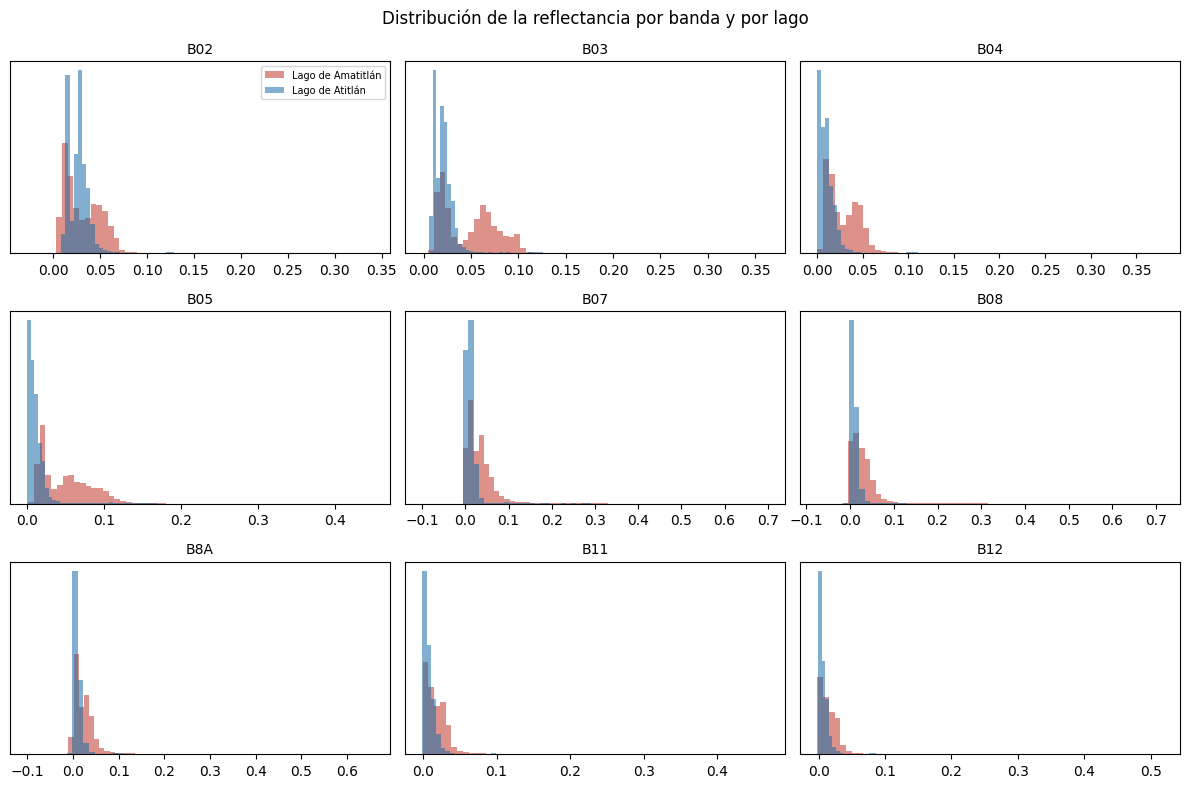

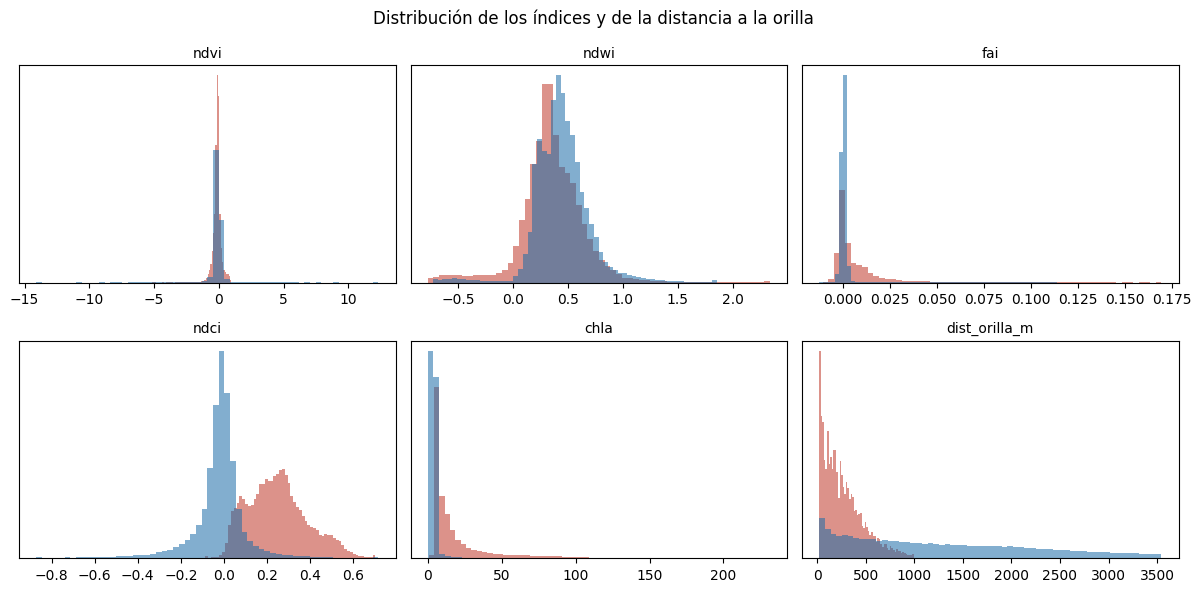

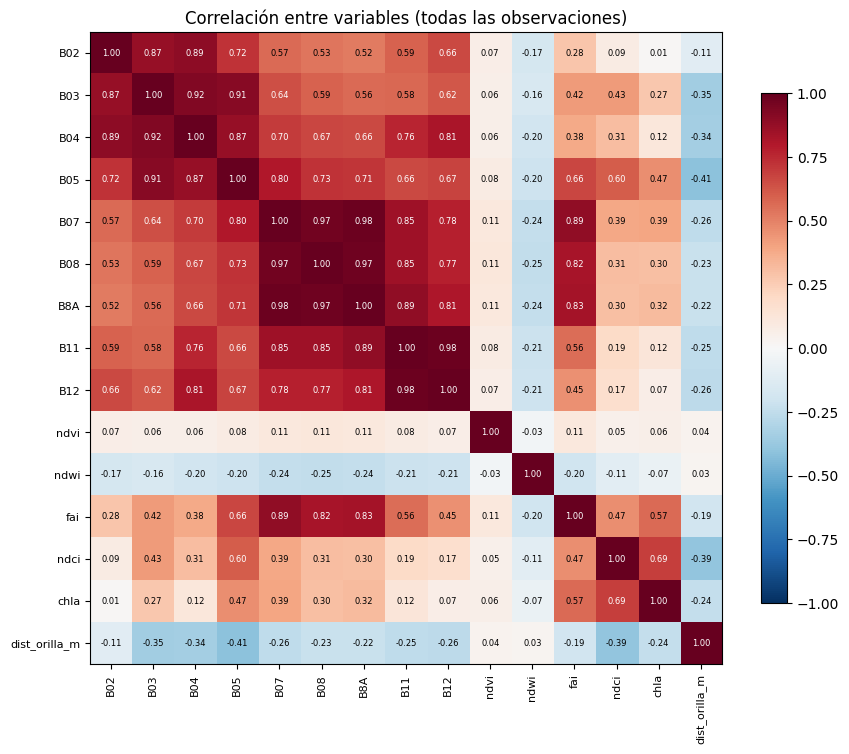

In [44]:
espectrales = ["B02","B03","B04","B05","B07","B08","B8A","B11","B12"]
derivadas   = ["ndvi","ndwi","fai","ndci","chla","dist_orilla_m"]

# --- Distribución de las bandas por lago ---
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for ax, b in zip(axes.ravel(), espectrales):
    for lago, sub in df.groupby("lago"):
        ax.hist(sub[b], bins=60, alpha=.55, color=COLOR[lago],
                label=NOMBRE[lago], density=True)
    ax.set_title(b, fontsize=10); ax.set_yticks([])
axes.ravel()[0].legend(fontsize=7)
fig.suptitle("Distribución de la reflectancia por banda y por lago")
fig.tight_layout(); fig.savefig(DIR_FIG / "eda_bandas.png", dpi=140); plt.show()

# --- Índices derivados ---
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, v in zip(axes.ravel(), derivadas):
    for lago, sub in df.groupby("lago"):
        ax.hist(sub[v].clip(sub[v].quantile(.001), sub[v].quantile(.999)),
                bins=60, alpha=.55, color=COLOR[lago], density=True)
    ax.set_title(v, fontsize=10); ax.set_yticks([])
fig.suptitle("Distribución de los índices y de la distancia a la orilla")
fig.tight_layout(); fig.savefig(DIR_FIG / "eda_indices.png", dpi=140); plt.show()

# --- Matriz de correlación ---
num = df[espectrales + derivadas].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(num, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(num))); ax.set_yticklabels(num.columns, fontsize=8)
for i in range(len(num)):
    for j in range(len(num)):
        ax.text(j, i, f"{num.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(num.iloc[i,j])>.6 else "black")
plt.colorbar(im, ax=ax, shrink=.8)
ax.set_title("Correlación entre variables (todas las observaciones)")
fig.tight_layout(); fig.savefig(DIR_FIG / "eda_correlacion.png", dpi=140); plt.show()

## 1.6 Decisiones tomadas durante la preparación

- **Unidad de observación: el píxel-fecha.** Es el nivel al que mide el sensor y al que
  se necesita predecir. Se conservan las coordenadas y la fecha de cada observación, tanto
  porque el enunciado lo pide como porque son indispensables para la validación espacial
  del ejercicio 6.
- **Se reutiliza la máscara de la Parte I** (límite oficial de OpenStreetMap, 96 % y 99 %
  de la superficie real). Delimitar el lago con un método automático por fecha habría
  excluido justamente los píxeles con floración, que son los que interesa detectar.
- **Se excluye la imagen de Atitlán del 18/01/2025** completa, por presentar reflectancia
  fuera de rango físico en el 75 % de su superficie. Incluirla habría introducido ruido
  etiquetado como señal.
- **Muestreo de hasta 15,000 píxeles por lago y fecha.** Equilibra el peso de ambos lagos
  y hace viable el ajuste de hiperparámetros y el cálculo de SHAP. Se documenta la semilla
  aleatoria para que el resultado sea reproducible.
- **No se imputan valores faltantes:** las observaciones incompletas se eliminan. Como el
  origen de un faltante es siempre una nube o un píxel inválido, imputarlo equivaldría a
  inventar una medición que el satélite no hizo.

---
# Ejercicio 2 — Construcción de la variable respuesta

## 2.1 – 2.2 Definición y justificación del punto de corte

Se define la variable binaria **`alta_cianobacteria`**:

- **1 (alta presencia):** clorofila-a estimada ≥ **10 µg/L**
- **0 (ausencia o baja presencia):** por debajo de ese valor

**Justificación del corte.** La Organización Mundial de la Salud establece, en sus guías para aguas de uso recreativo, un primer nivel de vigilancia en torno a los 10 µg/L de clorofila-a cuando el fitoplancton está dominado por cianobacterias; a partir de ese punto se recomienda señalización e inspección visual del cuerpo de agua (WHO, *Guidelines for safe recreational water environments*, Vol. 1, 2003; actualizadas en 2021). El mismo valor tiene respaldo desde la limnología: en la clasificación trófica de la OCDE (Vollenweider y Kerekes, 1982), la frontera entre condición mesotrófica y eutrófica se sitúa en 8 µg/L de clorofila-a media anual, y los 25 µg/L marcan el inicio de la condición hipereutrófica. Un corte en 10 µg/L separa el agua en condición aceptable del agua que ya requiere gestión.

Como el modelo empírico que convierte el índice en concentración (Chl-a = 826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071) es monótono creciente en el rango de interés, ese corte equivale exactamente a un umbral sobre el índice:

| Chl-a | NDCI equivalente | Interpretación |
|---|---|---|
| 10 µg/L | **+0.2413** | Nivel de Alerta 1 de la OMS — **corte usado** |
| 25 µg/L | +0.3523 | Inicio de condición hipereutrófica |
| 50 µg/L | +0.4438 | Nivel de Alerta 2 de la OMS |

Se mantiene el mismo criterio de la Parte I, de modo que los resultados de ambas partes son directamente comparables.

In [45]:
df["alta_cianobacteria"] = (df["chla"] >= UMBRAL_CHLA).astype(int)

# Verificación: el corte sobre Chl-a y sobre NDCI deben coincidir
coincide = (df["alta_cianobacteria"] == (df["ndci"] >= UMBRAL_NDCI).astype(int)).mean()
print(f"Coincidencia entre el corte por Chl-a y por NDCI: {100*coincide:.3f} %")
print(f"\nPositivos: {df.alta_cianobacteria.sum():,} de {len(df):,} "
      f"({100*df.alta_cianobacteria.mean():.2f} %)")

Coincidencia entre el corte por Chl-a y por NDCI: 99.996 %

Positivos: 86,185 de 315,000 (27.36 %)


## 2.3 Distribución de la variable respuesta

Distribución global:


,observaciones,porcentaje
alta_cianobacteria,,
0 = baja,228815,72.64
1 = alta,86185,27.36


Por lago:


,observaciones,positivos,porcentaje
lago,,,
amatitlan,165000,82340,49.90
atitlan,150000,3845,2.56


Por lago y fecha:


% de píxeles con alta presencia
lago      fecha                                      
amatitlan 2025-01-28                            64.85
          2025-04-15                            21.44
          2025-04-28                            38.53
          2025-11-24                            29.69
          2026-01-08                            77.72
          2026-02-02                             8.36
          2026-02-07                            22.89
          2026-03-29                            52.61
          2026-04-13                            81.21
          2026-04-28                            55.81
          2026-06-19                            95.83
atitlan   2025-04-13                             1.01
          2025-05-13                             1.28
          2025-07-17                             2.45
          2025-11-21                             7.93
          2025-12-29                             3.37
          2026-02-12                             3.93
          2026-03-24                             1.10
          2026-04-13                             1.46
          2026-04-28                             1.07
          2026-07-22                             2.03

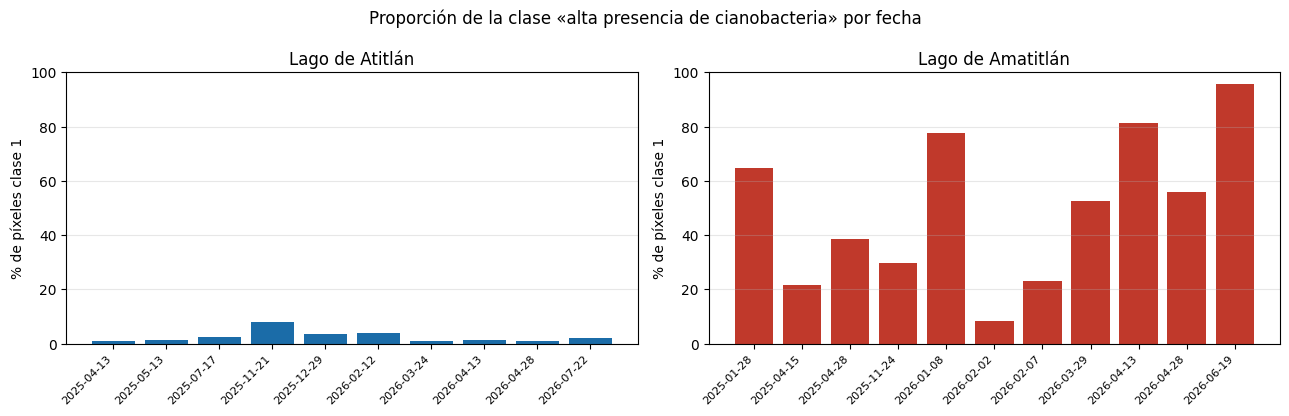

In [46]:
print("Distribución global:")
display(df.alta_cianobacteria.value_counts().rename({0:"0 = baja", 1:"1 = alta"})
        .rename("observaciones").to_frame()
        .assign(porcentaje=lambda t: (100*t.observaciones/len(df)).round(2)))

print("Por lago:")
por_lago = df.groupby("lago").alta_cianobacteria.agg(["size","sum","mean"])
por_lago.columns = ["observaciones","positivos","proporcion"]
por_lago["porcentaje"] = (100*por_lago.proporcion).round(2)
display(por_lago.drop(columns="proporcion"))

print("Por lago y fecha:")
por_fecha = (df.groupby(["lago","fecha"]).alta_cianobacteria.mean()*100).round(2)
display(por_fecha.rename("% de píxeles con alta presencia").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, lago in zip(axes, LAGOS):
    sub = df[df.lago == lago].groupby("fecha").alta_cianobacteria.mean()*100
    ax.bar(range(len(sub)), sub.values, color=COLOR[lago])
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in sub.index], rotation=45,
                       ha="right", fontsize=8)
    ax.set_title(NOMBRE[lago]); ax.set_ylabel("% de píxeles clase 1"); ax.set_ylim(0, 100)
    ax.grid(alpha=.3, axis="y")
fig.suptitle("Proporción de la clase «alta presencia de cianobacteria» por fecha")
fig.tight_layout(); fig.savefig(DIR_FIG / "respuesta_por_fecha.png", dpi=140); plt.show()

## 2.4 Desbalance entre clases

La proporción global de la clase positiva depende del diseño de muestreo: al tomar el
mismo número de píxeles por lago y fecha, ambos lagos pesan lo mismo, cuando en la
realidad Atitlán es ocho veces más grande. Conviene por tanto reportar el desbalance
global y por lago, e interpretarlo con esa advertencia.

**Consecuencias sobre el entrenamiento.** Un clasificador que minimice el error total
tiende a favorecer la clase mayoritaria. En el caso extremo de Atitlán, un modelo que
prediga siempre baja presencia acertaría en más del 95 % de los casos sin haber
aprendido nada útil, que es precisamente el error que hay que evitar.

**Consecuencias sobre la evaluación.** El accuracy es engañoso bajo desbalance, por la
razón anterior. Las métricas informativas aquí son el recall de la clase positiva, qué es la fracción de las zonas realmente afectadas que logra detectar el modelo, el F1 y el ROC-AUC, junto con la matriz de confusión. Desde el punto de vista ambiental, dejar de detectar una zona con floración (falso negativo) es más costoso que emitir una alerta que luego se descarta (falso positivo), lo que refuerza la prioridad del recall. Este punto se desarrolla en el ejercicio 5.3.

**Estrategias previstas** para el ejercicio 4: usar `class_weight="balanced"` en la
regresión logística y en Random Forest, `scale_pos_weight` en XGBoost, estratificar la
partición entrenamiento/prueba por la variable respuesta, y comparar los modelos por F1 y recall en lugar de por accuracy.

In [47]:
prop = df.alta_cianobacteria.mean()
print(f"Proporción global de la clase positiva: {100*prop:.2f} %  "
      f"(razón {(1-prop)/max(prop,1e-9):.1f} : 1 a favor de la clase 0)")
for lago, sub in df.groupby("lago"):
    p = sub.alta_cianobacteria.mean()
    razon = (1-p)/p if 0 < p < 1 else float("inf")
    print(f"  {NOMBRE[lago]:20s}: {100*p:6.2f} % positivos  (razón {razon:6.1f} : 1)")
print("\nPeso sugerido para la clase positiva (scale_pos_weight):",
      round((1-prop)/max(prop,1e-9), 2))

Proporción global de la clase positiva: 27.36 %  (razón 2.7 : 1 a favor de la clase 0)
  Lago de Amatitlán   :  49.90 % positivos  (razón    1.0 : 1)
  Lago de Atitlán     :   2.56 % positivos  (razón   38.0 : 1)

Peso sugerido para la clase positiva (scale_pos_weight): 2.65


## 2.5 Variables que no pueden usarse como predictoras

El enunciado advierte que una variable usada directa o indirectamente para construir la
respuesta no puede figurar después como predictora. Aquí la cadena de construcción es:

```
B04, B05  →  NDCI = (B05 − B04)/(B05 + B04)  →  Chl-a  →  alta_cianobacteria
```

Por lo tanto quedan excluidas:

| Variable | Razón |
|---|---|
| `chla` | Es la variable a partir de la cual se define la respuesta |
| `ndci` | La respuesta es un umbral sobre esta variable |
| `B05` | Banda del borde rojo que define el índice |
| `B04` | Banda roja que define el índice; junto con B05 lo reconstruye exactamente |

La celda siguiente demuestra empíricamente la fuga: un árbol de decisión entrenado
únicamente con B04 y B05 reproduce la etiqueta casi a la perfección. Ese resultado no
significa que el modelo sea bueno, sino que se le está dando la respuesta disfrazada de
predictor.

Un caso limítrofe que conviene declarar. El NDVI se calcula con B04 y B08, así que
comparte una banda con el índice. No constituye fuga: conocer el NDVI no permite
reconstruir el NDCI, porque falta B05. Se conserva como predictor dejando constancia del criterio. Lo mismo aplica al FAI, que usa B04, B07 y B8A pero no interviene en la construcción de la respuesta.

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

muestra = df.sample(min(40000, len(df)), random_state=SEMILLA)
y = muestra["alta_cianobacteria"]

fuga = cross_val_score(DecisionTreeClassifier(max_depth=6, random_state=SEMILLA),
                       muestra[["B04","B05"]], y, cv=3, scoring="roc_auc").mean()
limpio = cross_val_score(DecisionTreeClassifier(max_depth=6, random_state=SEMILLA),
                         muestra[["B02","B03","B08","B11","B12"]], y, cv=3,
                         scoring="roc_auc").mean()
print(f"ROC-AUC usando solo B04 y B05 (con fuga):        {fuga:.4f}")
print(f"ROC-AUC usando bandas sin relación con el índice: {limpio:.4f}")
print("\nLa diferencia confirma que B04 y B05 reconstruyen la respuesta y deben excluirse.")

ROC-AUC usando solo B04 y B05 (con fuga):        0.9713
ROC-AUC usando bandas sin relación con el índice: 0.9412

La diferencia confirma que B04 y B05 reconstruyen la respuesta y deben excluirse.


---
# Ejercicio 3 — Selección y construcción de variables predictoras

## 3.1 – 3.2 Conjunto de predictoras

| Variable | Tipo | Qué representa | Por qué podría ayudar |
|---|---|---|---|
| `B02` | Banda espectral (azul, 490 nm) | Reflectancia en el azul | Las cianobacterias absorben fuertemente en el azul; también es sensible a turbidez |
| `B03` | Banda espectral (verde, 560 nm) | Reflectancia en el verde | El pico de reflectancia verde es la firma visible de una floración |
| `B08` | Banda espectral (NIR, 842 nm) | Infrarrojo cercano | La biomasa flotante refleja intensamente en el NIR; el agua limpia lo absorbe |
| `B07` | Banda espectral (NIR, 783 nm) | Borde del infrarrojo | Sensible a biomasa superficial; vecina al borde rojo (ver advertencia en 2.5) |
| `B8A` | Banda espectral (NIR estrecho, 865 nm) | Infrarrojo cercano estrecho | Complementa a B08 con menor influencia del vapor de agua |
| `B11`, `B12` | Bandas espectrales (SWIR) | Infrarrojo de onda corta | Separan agua de superficies no acuáticas y detectan materia flotante densa |
| `ndvi` | Índice espectral | Vigor de vegetación | Sobre agua, valores altos delatan biomasa fotosintética en superficie |
| `ndwi` | Índice espectral | Presencia de agua abierta | Disminuye cuando la superficie se cubre de biomasa |
| `fai` | Índice espectral | Floating Algal Index | Diseñado para detectar nata flotante, la manifestación visible de una floración severa |
| `dist_orilla_m` | Característica espacial | Distancia al borde del lago, en metros | Las floraciones se concentran cerca de la orilla y de las desembocaduras; el centro del lago suele estar más limpio |
| `lago` | Característica geográfica | Cuerpo de agua | Codifica el régimen ecológico: Amatitlán es somero y eutrófico, Atitlán profundo y oligotrófico |
| `mes_sin`, `mes_cos` | Característica temporal | Posición en el ciclo anual | Permite capturar estacionalidad sin imponer un orden artificial entre diciembre y enero |
| `estacion_lluviosa` | Característica temporal | Época seca o lluviosa | Las lluvias arrastran nutrientes desde la cuenca |
| `x_utm`, `y_utm` | Coordenadas métricas | Posición en UTM 15N | Necesarias para la validación espacial del ejercicio 6 |

**Excluidas por fuga:** `chla`, `ndci`, `B04`, `B05` (ver 2.5).
**Excluidas por ser auxiliares:** `fila`, `col`, `nata` (derivada de un umbral sobre FAI,
redundante con la variable continua).

## 3.3 Ingeniería de características

Se construyen cuatro grupos de variables adicionales, todas ellas sin usar B04 ni B05:

1. **Distancia a la orilla** (`dist_orilla_m`). Calculada sobre la máscara del lago con una
   transformada de distancia. Es la variable espacial con sentido ecológico más directo:
   distingue el centro del lago de las zonas someras de ribera donde se acumula la biomasa.
2. **Coordenadas métricas** (`x_utm`, `y_utm`), reproyectadas a WGS 84 / UTM 15N. Además de
   ser requisito del ejercicio 6, permiten al modelo aprender gradientes geográficos —por
   ejemplo, el gradiente noroeste-sureste de Amatitlán detectado en la Parte I.
3. **Codificación cíclica del tiempo** (`mes_sin`, `mes_cos`). Convierte el mes en dos
   coordenadas sobre una circunferencia, de modo que diciembre y enero quedan próximos
   entre sí, cosa que no ocurriría usando el número de mes directamente.
4. **Cocientes espectrales seguros** (`ratio_verde_azul`, `ratio_nir_verde`). El primero
   crece cuando el agua se vuelve más verde, firma característica del pigmento; el segundo
   detecta biomasa flotante. Ambos usan únicamente B02, B03 y B08, sin tocar las bandas del
   índice.

In [49]:
# --- Coordenadas métricas (EPSG:32615), requeridas por el ejercicio 6 ---
xs, ys = warp_transform("EPSG:4326", CRS_METRICO,
                        df["lon"].tolist(), df["lat"].tolist())
df["x_utm"] = np.asarray(xs, np.float32)
df["y_utm"] = np.asarray(ys, np.float32)

# --- Temporales ---
mes = df["fecha"].dt.month
df["mes_sin"] = np.sin(2*np.pi*mes/12).astype(np.float32)
df["mes_cos"] = np.cos(2*np.pi*mes/12).astype(np.float32)
df["estacion_lluviosa"] = (df["estacion"] == "Lluviosa").astype(int)
df["es_amatitlan"] = (df["lago"] == "amatitlan").astype(int)

# --- Cocientes espectrales que no usan B04 ni B05 ---
df["ratio_verde_azul"] = (df["B03"] / df["B02"].replace(0, np.nan)).astype(np.float32)
df["ratio_nir_verde"]  = (df["B08"] / df["B03"].replace(0, np.nan)).astype(np.float32)

PREDICTORAS = ["B02","B03","B07","B08","B8A","B11","B12",
               "ndvi","ndwi","fai",
               "dist_orilla_m","x_utm","y_utm",
               "mes_sin","mes_cos","estacion_lluviosa","es_amatitlan",
               "ratio_verde_azul","ratio_nir_verde"]
EXCLUIDAS_POR_FUGA = ["chla","ndci","B04","B05"]

antes = len(df)
df = df.dropna(subset=PREDICTORAS + ["alta_cianobacteria"]).reset_index(drop=True)
print(f"Filas eliminadas por valores faltantes: {antes-len(df):,}")
print(f"Conjunto final: {len(df):,} observaciones × {len(PREDICTORAS)} predictoras")
print(f"\nPredictoras: {', '.join(PREDICTORAS)}")
print(f"Excluidas por fuga: {', '.join(EXCLUIDAS_POR_FUGA)}")

# Comprobación de seguridad: ninguna predictora debe estar casi perfectamente
# correlacionada con la variable respuesta
corr_y = df[PREDICTORAS].corrwith(df["alta_cianobacteria"]).abs().sort_values(ascending=False)
print("\nCorrelación absoluta de cada predictora con la respuesta:")
display(corr_y.round(3).to_frame("|correlación|"))
if (corr_y > 0.95).any():
    print("AVISO: revise las variables con correlación > 0.95, podrían implicar fuga.")

Filas eliminadas por valores faltantes: 104
Conjunto final: 314,896 observaciones × 19 predictoras

Predictoras: B02, B03, B07, B08, B8A, B11, B12, ndvi, ndwi, fai, dist_orilla_m, x_utm, y_utm, mes_sin, mes_cos, estacion_lluviosa, es_amatitlan, ratio_verde_azul, ratio_nir_verde
Excluidas por fuga: chla, ndci, B04, B05

Correlación absoluta de cada predictora con la respuesta:


,|correlación|
ratio_verde_azul,0.532
es_amatitlan,0.530
x_utm,0.520
y_utm,0.507
fai,0.429
B03,0.360
dist_orilla_m,0.356
B07,0.322
B08,0.250
B8A,0.235


### Guardado del conjunto de datos para las secciones siguientes

In [50]:
COLUMNAS = (["lago","fecha","estacion","lon","lat","fila","col"]
            + PREDICTORAS + EXCLUIDAS_POR_FUGA + ["alta_cianobacteria"])

try:
    RUTA_DATASET = PARQUET
    df[COLUMNAS].to_parquet(RUTA_DATASET, index=False)
except Exception as exc:
    print(f"Parquet no disponible ({type(exc).__name__}), se guarda como CSV comprimido.")
    RUTA_DATASET = DIR_ML / "dataset_ml.csv.gz"
    df[COLUMNAS].to_csv(RUTA_DATASET, index=False, compression="gzip")

print(f"Guardado: {RUTA_DATASET}  ({RUTA_DATASET.stat().st_size/1e6:.1f} MB)")

with open(DIR_ML / "predictoras.json", "w", encoding="utf-8") as fh:
    json.dump({"predictoras": PREDICTORAS,
               "excluidas_por_fuga": EXCLUIDAS_POR_FUGA,
               "umbral_chla": UMBRAL_CHLA,
               "umbral_ndci": UMBRAL_NDCI,
               "max_por_fecha": MAX_POR_FECHA,
               "semilla": SEMILLA,
               "archivo_dataset": RUTA_DATASET.name}, fh, indent=2, ensure_ascii=False)
print("Guardado: datos/ml/predictoras.json")

print("\nLas secciones 4 en adelante deben cargar el conjunto así:")
if RUTA_DATASET.suffix == ".parquet":
    print('    df = pd.read_parquet(RUTA_DATASET)')
else:
    print('    df = pd.read_csv(RUTA_DATASET, parse_dates=["fecha"])')

Parquet no disponible (ArrowKeyError), se guarda como CSV comprimido.
Guardado: c:\Users\nicky\OneDrive\Documentos\An-lisis-Geoespacial-y-sensores-remotos\datos\ml\dataset_ml.csv.gz  (23.3 MB)
Guardado: datos/ml/predictoras.json

Las secciones 4 en adelante deben cargar el conjunto así:
    df = pd.read_csv(RUTA_DATASET, parse_dates=["fecha"])
